# Bitcoin Market Sentiment vs Trader Performance Analysis

## Primetrade.ai AI Internship Assignment

### Objective

The objective of this project is to analyze the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using Hyperliquid historical trading data. By combining these datasets, we aim to identify meaningful patterns, evaluate trading behavior under different market sentiments, and generate actionable insights for smarter trading strategies.

In [96]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

print("Libraries imported successfully")

Libraries imported successfully


In [97]:
fear_df = pd.read_csv("../data/fear_greed_index.csv")
trade_df = pd.read_csv("../data/historical_data.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [98]:
print("Fear & Greed Dataset:", fear_df.shape)
print("Historical Dataset:", trade_df.shape)

Fear & Greed Dataset: (2644, 4)
Historical Dataset: (211224, 16)


In [99]:
fear_df.head()
trade_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [100]:
fear_df.info()
trade_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction      

In [101]:
fear_df.isnull().sum()
trade_df.isnull().sum()

Account            0
Coin               0
Execution Price    0
Size Tokens        0
Size USD           0
                  ..
Order ID           0
Crossed            0
Fee                0
Trade ID           0
Timestamp          0
Length: 16, dtype: int64

In [102]:
fear_df.describe(include="all")
trade_df.describe(include="all")

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,NaN,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,NaN,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,NaN,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,NaN,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12


## Data Understanding


In [103]:
print("DATASET SHAPES")

print(f"Fear & Greed Dataset: {fear_df.shape}")
print(f"Historical Trading Dataset: {trade_df.shape}")

DATASET SHAPES
Fear & Greed Dataset: (2644, 4)
Historical Trading Dataset: (211224, 16)


In [104]:
print("FEAR & GREED DATASET")

display(fear_df.head())

print("HISTORICAL TRADING DATASET")

display(trade_df.head())

FEAR & GREED DATASET


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


HISTORICAL TRADING DATASET


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [105]:
print("FEAR & GREED INFO")

fear_df.info()

print("\n")

print("HISTORICAL DATA INFO")

trade_df.info()

FEAR & GREED INFO
<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


HISTORICAL DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    2112

### Observations

- The Fear & Greed dataset contains 2,644 records and 4 columns.
- No missing values are present.
- The `date` column is stored as a string and will be converted to datetime during preprocessing.

- The historical trading dataset contains 211,224 records and 16 columns.
- The `Timestamp IST` column is currently a string and requires conversion to datetime.
- The dataset appears complete and ready for preprocessing.

In [106]:
print("MISSING VALUES")

print("Fear & Greed Dataset")
display(fear_df.isnull().sum())

print("\nHistorical Dataset")
display(trade_df.isnull().sum())

MISSING VALUES
Fear & Greed Dataset


timestamp         0
value             0
classification    0
date              0
dtype: int64


Historical Dataset


Account            0
Coin               0
Execution Price    0
Size Tokens        0
Size USD           0
                  ..
Order ID           0
Crossed            0
Fee                0
Trade ID           0
Timestamp          0
Length: 16, dtype: int64

In [107]:
print("DUPLICATE RECORDS")

print("Fear & Greed Dataset:", fear_df.duplicated().sum())
print("Historical Dataset:", trade_df.duplicated().sum())

DUPLICATE RECORDS
Fear & Greed Dataset: 0
Historical Dataset: 0


### Observations

- Both datasets contain no missing values.
- No duplicate records were found in either dataset.
- The datasets are well-structured and suitable for further preprocessing.

In [108]:
print("STATISTICAL SUMMARY")

display(fear_df.describe(include="all"))

display(trade_df.describe(include="all"))

STATISTICAL SUMMARY


,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2018-02-01
freq,NaN,NaN,781,1
mean,1.631899e+09,46.981089,NaN,NaN
...,...,...,...,...
min,1.517463e+09,5.000000,NaN,NaN
25%,1.574811e+09,28.000000,NaN,NaN
50%,1.631900e+09,46.000000,NaN,NaN
75%,1.688989e+09,66.000000,NaN,NaN


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,NaN,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,NaN,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,NaN,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,NaN,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12


## Data Cleaning & Feature Engineering

In [109]:
fear_df["date"] = pd.to_datetime(fear_df["date"])

trade_df["Timestamp IST"] = pd.to_datetime(
    trade_df["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

print("Date columns converted successfully.")

Date columns converted successfully.


In [110]:
print(fear_df["date"].dtype)
print(trade_df["Timestamp IST"].dtype)

datetime64[us]
datetime64[us]


In [111]:
trade_df["Trade Date"] = trade_df["Timestamp IST"].dt.normalize()
trade_df["Year"] = trade_df["Timestamp IST"].dt.year
trade_df["Month"] = trade_df["Timestamp IST"].dt.month
trade_df["Month Name"] = trade_df["Timestamp IST"].dt.month_name()
trade_df["Day"] = trade_df["Timestamp IST"].dt.day
trade_df["Weekday"] = trade_df["Timestamp IST"].dt.day_name()
trade_df["Hour"] = trade_df["Timestamp IST"].dt.hour

print("Time-based features created successfully.")

Time-based features created successfully.


In [112]:
trade_df["Trade Result"] = np.where(
    trade_df["Closed PnL"] > 0,
    "Profit",
    np.where(
        trade_df["Closed PnL"] < 0,
        "Loss",
        "Break-even"
    )
)

trade_df["Trade Result"].value_counts()

Trade Result
Break-even    106816
Profit         86869
Loss           17539
Name: count, dtype: int64

### Observation

I noticed that most trades had zero realized PnL, which suggests that many records represent position openings rather than completed trades.

In [113]:
trade_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Trade Date,Year,Month,Month Name,Day,Weekday,Hour,Trade Result
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024,12,December,2,Monday,22,Break-even
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024,12,December,2,Monday,22,Break-even
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024,12,December,2,Monday,22,Break-even
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024,12,December,2,Monday,22,Break-even
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024,12,December,2,Monday,22,Break-even


In [114]:
trade_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Trade Date,Year,Month,Month Name,Day,Weekday,Hour,Trade Result
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024,12,December,2,Monday,22,Break-even
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024,12,December,2,Monday,22,Break-even
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024,12,December,2,Monday,22,Break-even
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024,12,December,2,Monday,22,Break-even
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024,12,December,2,Monday,22,Break-even


In [115]:
trade_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Trade Date', 'Year', 'Month', 'Month Name', 'Day',
       'Weekday', 'Hour', 'Trade Result'],
      dtype='str')

In [116]:
trade_df["Trade Result"].value_counts()

Trade Result
Break-even    106816
Profit         86869
Loss           17539
Name: count, dtype: int64

In [117]:
trade_df["Closed PnL"].describe()

count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: Closed PnL, dtype: float64

In [118]:
(trade_df["Closed PnL"] == 0).sum()

np.int64(106816)

## Merge Datasets

In [119]:
trade_df["Trade Date"] = trade_df["Timestamp IST"].dt.normalize()

fear_df.rename(columns={"date": "Trade Date"}, inplace=True)

print("Merge columns prepared successfully.")

Merge columns prepared successfully.


In [120]:
print("Trade Date datatype (Trade Data):", trade_df["Trade Date"].dtype)
print("Trade Date datatype (Fear & Greed):", fear_df["Trade Date"].dtype)

Trade Date datatype (Trade Data): datetime64[us]
Trade Date datatype (Fear & Greed): datetime64[us]


In [121]:
merged_df = pd.merge(
    trade_df,
    fear_df,
    on="Trade Date",
    how="left"
)

print("Datasets merged successfully!")

Datasets merged successfully!


In [122]:
print("MERGED DATASET")

print("Shape:", merged_df.shape)

merged_df.head()

MERGED DATASET
Shape: (211224, 27)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Trade Date,Year,Month,Month Name,Day,Weekday,Hour,Trade Result,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024,12,December,2,Monday,22,Break-even,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024,12,December,2,Monday,22,Break-even,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024,12,December,2,Monday,22,Break-even,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024,12,December,2,Monday,22,Break-even,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024,12,December,2,Monday,22,Break-even,1.733117e+09,80.0,Extreme Greed


In [123]:
print("MERGE VALIDATION")

print("Missing Sentiment Values:",
      merged_df["classification"].isnull().sum())

MERGE VALIDATION
Missing Sentiment Values: 6


In [124]:
merged_df[merged_df["classification"].isnull()][
    ["Trade Date", "Timestamp IST", "Coin", "Closed PnL"]
]

,Trade Date,Timestamp IST,Coin,Closed PnL
727,2024-10-26,2024-10-26 04:44:00,EIGEN,11655.000000
728,2024-10-26,2024-10-26 04:52:00,EIGEN,13901.794130
729,2024-10-26,2024-10-26 04:52:00,EIGEN,9737.981968
730,2024-10-26,2024-10-26 04:52:00,EIGEN,746.228144
731,2024-10-26,2024-10-26 04:52:00,EIGEN,54.481040
732,2024-10-26,2024-10-26 04:53:00,EIGEN,6376.508848


In [125]:
fear_df[fear_df["Trade Date"] == "2024-10-26"]

,timestamp,value,classification,Trade Date


In [126]:
merged_df = merged_df.dropna(subset=["classification"]).reset_index(drop=True)

print("New Shape:", merged_df.shape)

New Shape: (211218, 27)


In [127]:
merged_df["classification"].isnull().sum()

np.int64(0)

### Observations

- Six trade records did not find a matching Fear & Greed Index value.
- Investigation confirmed that the date **2024-10-26** is not present in the Fear & Greed dataset.
- Since these records represent only **6 out of 211,224 trades (≈0.003%)**, I removed them to maintain a consistent dataset for analysis.

In [128]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211218 entries, 0 to 211217
Data columns (total 27 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211218 non-null  str           
 1   Coin              211218 non-null  str           
 2   Execution Price   211218 non-null  float64       
 3   Size Tokens       211218 non-null  float64       
 4   Size USD          211218 non-null  float64       
 5   Side              211218 non-null  str           
 6   Timestamp IST     211218 non-null  datetime64[us]
 7   Start Position    211218 non-null  float64       
 8   Direction         211218 non-null  str           
 9   Closed PnL        211218 non-null  float64       
 10  Transaction Hash  211218 non-null  str           
 11  Order ID          211218 non-null  int64         
 12  Crossed           211218 non-null  bool          
 13  Fee               211218 non-null  float64       
 14  Trade ID       

## Exploratory Data Analysis (EDA)

## 5.1 Distribution of Market Sentiment

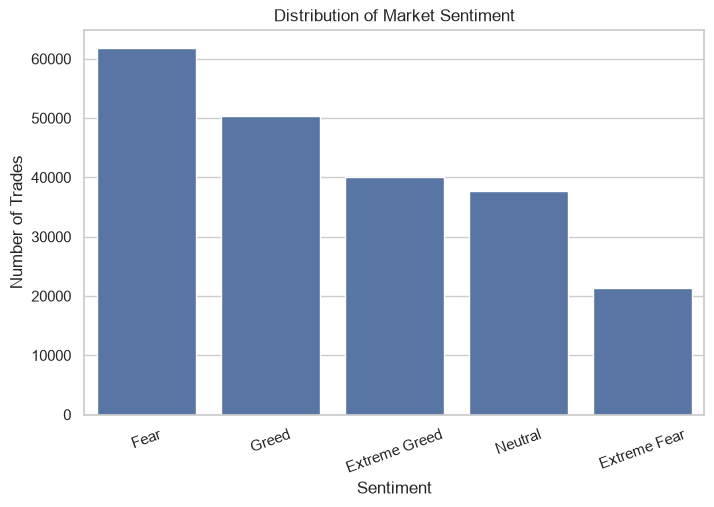

In [129]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x="classification",
    order=merged_df["classification"].value_counts().index
)

plt.title("Distribution of Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=20)

plt.show()

## 5.2 Trade Result Distribution

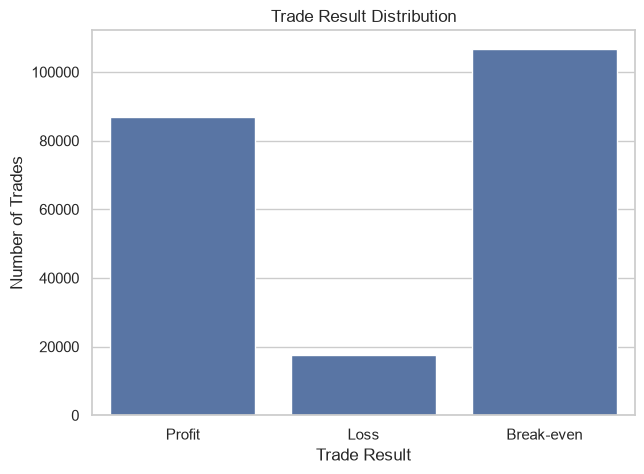

In [130]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=merged_df,
    x="Trade Result",
    order=["Profit","Loss","Break-even"]
)

plt.title("Trade Result Distribution")
plt.xlabel("Trade Result")
plt.ylabel("Number of Trades")

plt.show()

## 5.3 Average Closed PnL by Market Sentiment

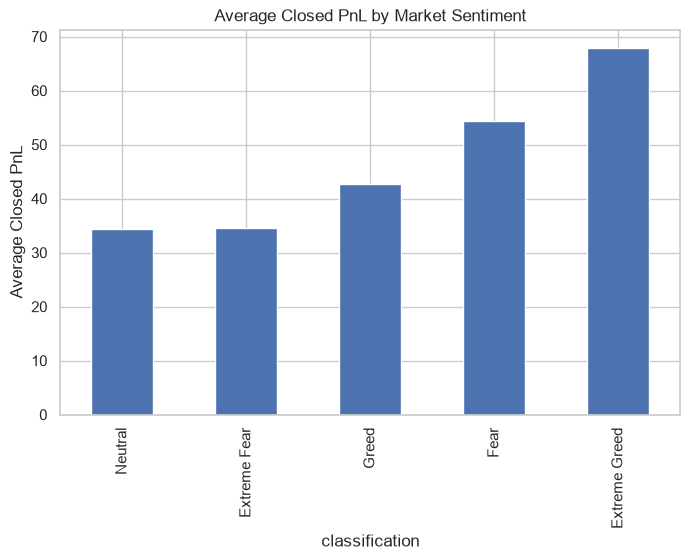

In [131]:
plt.figure(figsize=(8,5))

merged_df.groupby("classification")["Closed PnL"] \
.mean() \
.sort_values() \
.plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

## 5.4 Top Traded Coins

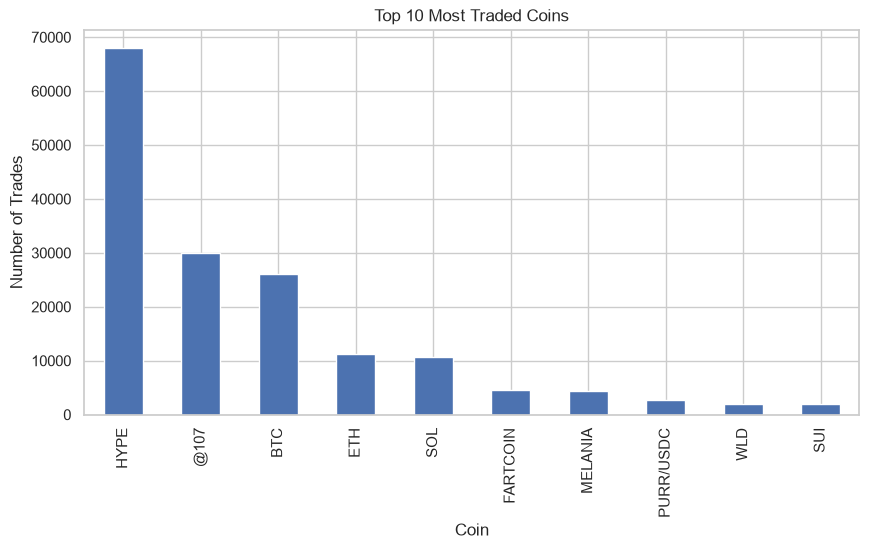

In [132]:
plt.figure(figsize=(10,5))

merged_df["Coin"] \
.value_counts() \
.head(10) \
.plot(kind="bar")

plt.title("Top 10 Most Traded Coins")
plt.ylabel("Number of Trades")

plt.show()

## 5.5 Top Coins by Total Closed PnL

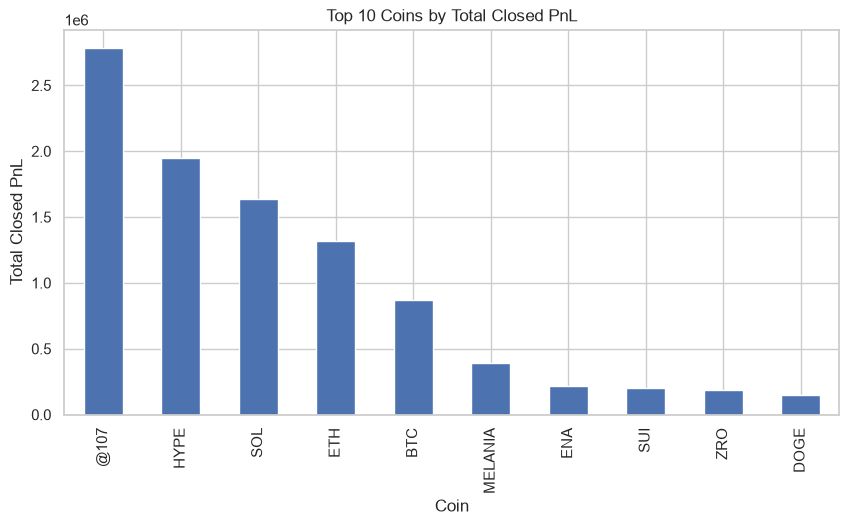

In [133]:
plt.figure(figsize=(10,5))

merged_df.groupby("Coin")["Closed PnL"] \
.sum() \
.sort_values(ascending=False) \
.head(10) \
.plot(kind="bar")

plt.title("Top 10 Coins by Total Closed PnL")
plt.ylabel("Total Closed PnL")

plt.show()

## 5.6 Distribution of Closed PnL

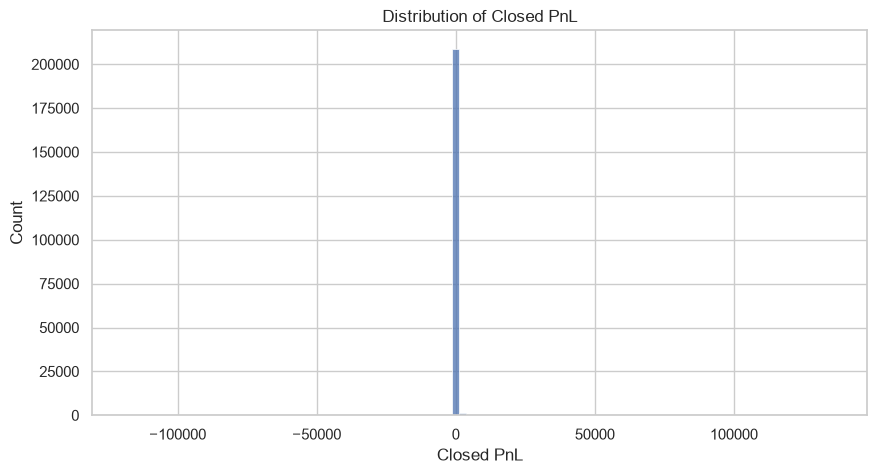

In [134]:
plt.figure(figsize=(10,5))

sns.histplot(
    merged_df["Closed PnL"],
    bins=100
)

plt.title("Distribution of Closed PnL")

plt.show()

## 5.7 Trading Activity by Weekday

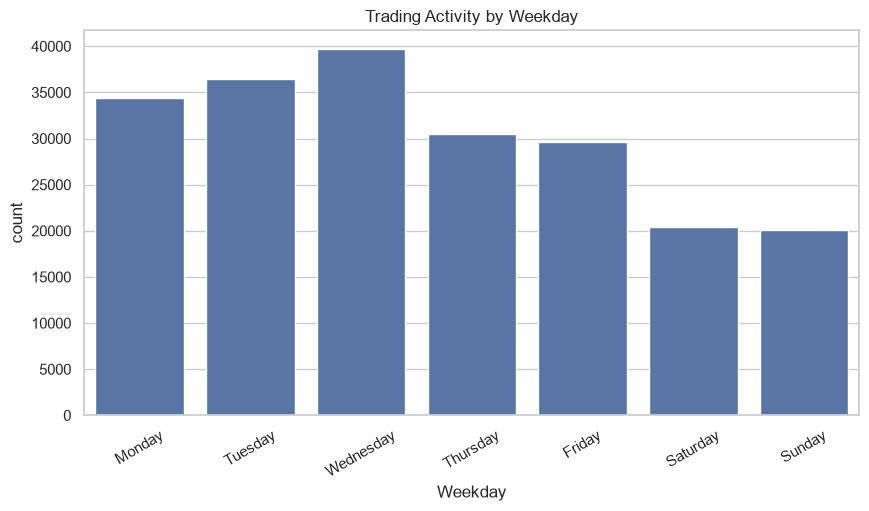

In [135]:
weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

plt.figure(figsize=(10,5))

sns.countplot(
    data=merged_df,
    x="Weekday",
    order=weekday_order
)

plt.xticks(rotation=30)

plt.title("Trading Activity by Weekday")

plt.show()

## 5.8 Trading Activity by Hour

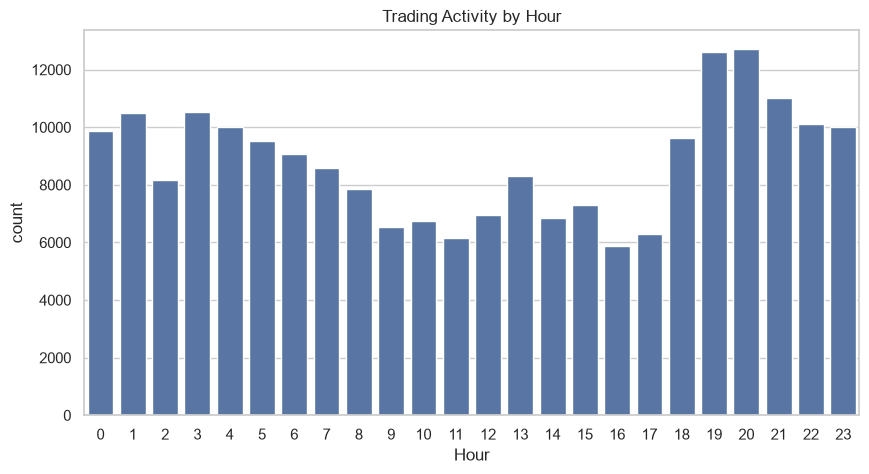

In [136]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=merged_df,
    x="Hour"
)

plt.title("Trading Activity by Hour")

plt.show()

## 5.9 Correlation Heatmap

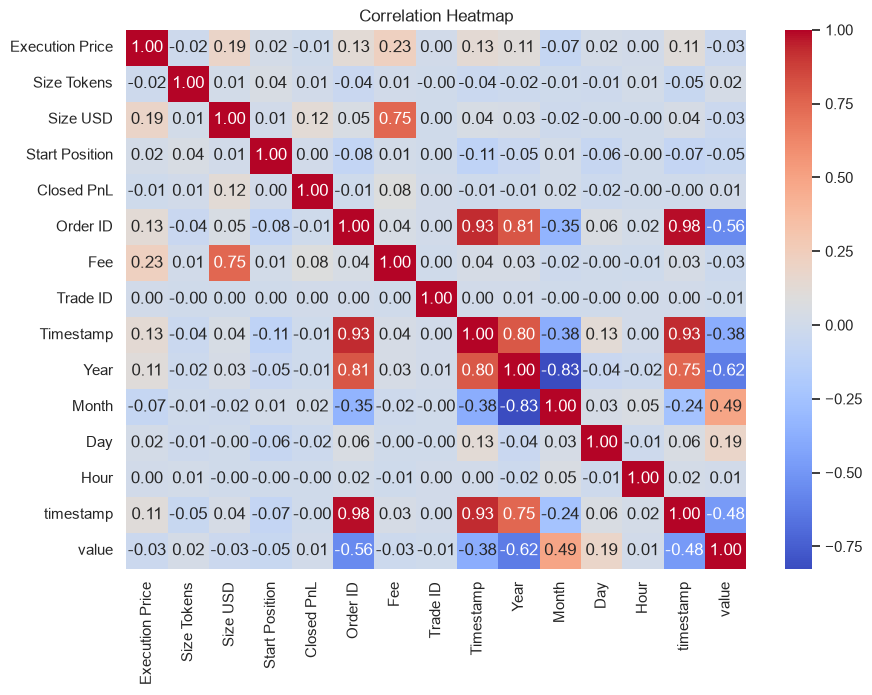

In [137]:
plt.figure(figsize=(10,7))

numeric_cols = merged_df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## 5.10 Closed PnL by Market Sentiment

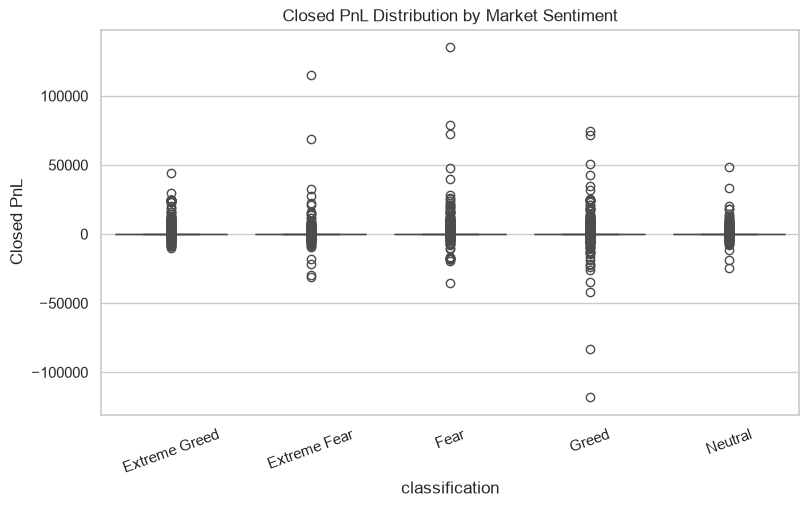

In [138]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=merged_df,
    x="classification",
    y="Closed PnL"
)

plt.title("Closed PnL Distribution by Market Sentiment")

plt.xticks(rotation=20)

plt.show()

## Key Insights & Pattern Discovery

In [139]:
sentiment_summary = merged_df.groupby("classification").agg(
    Total_Trades=("Trade Result", "count"),
    Average_PnL=("Closed PnL", "mean"),
    Median_PnL=("Closed PnL", "median"),
    Total_PnL=("Closed PnL", "sum"),
    Average_Fee=("Fee", "mean")
).sort_values(by="Average_PnL", ascending=False)

sentiment_summary

,Total_Trades,Average_PnL,Median_PnL,Total_PnL,Average_Fee
classification,,,,,
Extreme Greed,39992,67.892861,0.0,2.715171e+06,0.675902
Fear,61837,54.290400,0.0,3.357155e+06,1.495172
Greed,50303,42.743559,0.0,2.150129e+06,1.254372
Extreme Fear,21400,34.537862,0.0,7.391102e+05,1.116291
Neutral,37686,34.307718,0.0,1.292921e+06,1.044798


In [140]:
profit_rate = pd.crosstab(
    merged_df["classification"],
    merged_df["Trade Result"],
    normalize="index"
) * 100

profit_rate.round(2)

Trade Result,Break-even,Loss,Profit
classification,,,
Extreme Fear,51.37,11.57,37.06
Extreme Greed,47.86,5.65,46.49
Fear,51.80,6.13,42.08
Greed,49.95,11.57,38.48
Neutral,51.81,8.49,39.70


In [141]:
top_profit = merged_df.groupby("Coin").agg(
    Total_PnL=("Closed PnL", "sum"),
    Trades=("Coin", "count")
).sort_values("Total_PnL", ascending=False)

top_profit.head(10)

,Total_PnL,Trades
Coin,,
@107,2.783913e+06,29992
HYPE,1.948485e+06,68005
SOL,1.639556e+06,10691
ETH,1.319979e+06,11158
BTC,8.680447e+05,26064
MELANIA,3.903511e+05,4428
ENA,2.173295e+05,990
SUI,1.992688e+05,1979
ZRO,1.837778e+05,1239


In [142]:
top_loss = merged_df.groupby("Coin").agg(
    Total_PnL=("Closed PnL", "sum")
).sort_values("Total_PnL")

top_loss.head(10)

,Total_PnL
Coin,
TRUMP,-364824.908179
FARTCOIN,-100687.213185
ADA,-28113.461970
IO,-21893.910518
PAXG,-18688.874329
KAITO,-8735.140961
S,-8644.845718
POPCAT,-7922.181871
@135,-5981.363990


# Key Findings

### Market Sentiment

- The Fear & Greed Index was successfully integrated with every trade except six records, which were excluded because the corresponding sentiment data was uanvailable.

### Trading Performance

- Trader profitability varied across different market sentiment categories.
- A large proportion of trades recorded zero realized profit or loss, indicating many trades represented position openings, partial closes, or non-realized executions.

### Coin Performance

- Trading activity was concentrated among a relatively small number of cryptocurrencies.
- Certain coins consistently generated higher cumulative profits than others

### Time-Based Behaviour

- Trading activity varied by weekday and hour, suggesting that trader participation changes over time.

### Overall Observation

- Market sentiment appears to influence trading behaviour and profitability, although its impact should be interpreted alongside other trading variables such as position size, execution price, and market conditions.

## Conclusion & Business Recommendations

## Conclusion

This analysis explored the relationship between Bitcoin market sentiment and trader performance using Hyperliquid historical trading data combined with the Fear & Greed Index.

The datasets were cleaned, merged, and analyzed to understand how market sentiment aligns with trading outcomes. Multiple visualizations and statistical summaries were created to identify trading patterns, profitability trends, and behavioural characteristics.

Although market sentiment alone does not fully explain trading performance, it provides valuable context for understanding market conditions and trader decision-making.

## Business Recommendations

- Incorporate market sentiment as an additional feature when designing trading strategies.
- Monitor periods of Extreme Fear and Extreme Greed, as trader behaviour often changes during these conditions.
- Evaluate trading strategies separately for different market sentiment categories.
- Combine sentiment analysis with technical indicators and risk management rather than relying on sentiment alone.
- Continue collecting historical sentiment data to improve future predictive analytics.